In [1]:
from service.dataservice.DataService import DataService

dataset_service = DataService()

%load_ext autoreload
%autoreload 2

# Kolmogorov Smirnov Test

In [16]:
from scipy.stats import ks_2samp

data_list = list()
for subject in range(2, 36):
    x, _ = dataset_service.get_subject_data(subject=subject, with_features=True)
    _dict = {
        "subject": subject,
        "data": x
    }
    data_list.append(_dict)

for distribution_1 in data_list:
    for distribution_2 in data_list:
        if distribution_1["subject"] != distribution_2["subject"]:
            p_values = ks_2samp(distribution_1["data"]["Deriv_2_RESPR_mean"], distribution_2["data"]["Deriv_2_RESPR_mean"]).pvalue
            if p_values > 0.05:
                print(f"Subject {distribution_1['subject']} and Subject {distribution_2['subject']} have a similar HR: p_value: {p_values}")
            if p_values > 0.05:
                print(f"Subject {distribution_1['subject']} and Subject {distribution_2['subject']} have a similar RR: p_value: {p_values}")

Subject 2 and Subject 10 have a similar HR: p_value: 0.9743547272402832
Subject 2 and Subject 10 have a similar RR: p_value: 0.9743547272402832
Subject 2 and Subject 11 have a similar HR: p_value: 0.5066337203244083
Subject 2 and Subject 11 have a similar RR: p_value: 0.5066337203244083
Subject 2 and Subject 15 have a similar HR: p_value: 0.14366166035385936
Subject 2 and Subject 15 have a similar RR: p_value: 0.14366166035385936
Subject 2 and Subject 16 have a similar HR: p_value: 0.09002325281604628
Subject 2 and Subject 16 have a similar RR: p_value: 0.09002325281604628
Subject 2 and Subject 22 have a similar HR: p_value: 0.20305858162794624
Subject 2 and Subject 22 have a similar RR: p_value: 0.20305858162794624
Subject 2 and Subject 23 have a similar HR: p_value: 0.4671418792332801
Subject 2 and Subject 23 have a similar RR: p_value: 0.4671418792332801
Subject 2 and Subject 30 have a similar HR: p_value: 0.4949541871243409
Subject 2 and Subject 30 have a similar RR: p_value: 0.494

# Dynamic Time Warping

In [11]:
from fastdtw import fastdtw

data_list = list()
for subject in range(2, 36):
    x, _ = dataset_service.get_subject_data(subject=subject, with_features=False)
    _dict = {
        "subject": subject,
        "data": x
    }
    data_list.append(_dict)

results = list()
for distribution_1 in data_list:
    for distribution_2 in data_list:
        if distribution_1["subject"] != distribution_2["subject"]:
            hr_1 = distribution_1["data"]["HR"].to_numpy()
            hr_2 = distribution_2["data"]["HR"].to_numpy()
            rr_1 = distribution_1["data"]["respr"].to_numpy()
            rr_2 = distribution_2["data"]["respr"].to_numpy()
            distance_hr, _ = fastdtw(hr_1, hr_2, dist=2)
            distance_rr, _ = fastdtw(rr_1, rr_2, dist=2)
            _dict = {
                f"{distribution_1['subject']}_{distribution_2['subject']}": {
                    "hr": distance_hr,
                    "rr": distance_rr
                }
            }
            results.append(_dict)

results.sort(key=lambda x: x[list(x.keys())[0]]["hr"])
print(results)

[{'7_24': {'hr': 4559.020000000048, 'rr': 3163.4443664100068}}, {'24_7': {'hr': 4559.020000000048, 'rr': 3163.4443664100068}}, {'21_24': {'hr': 5679.490000000119, 'rr': 1901.4672143099945}}, {'24_21': {'hr': 5679.490000000119, 'rr': 1901.4672143099945}}, {'6_24': {'hr': 5729.680000000019, 'rr': 1380.5960812899978}}, {'24_6': {'hr': 5729.680000000019, 'rr': 1380.5960812899978}}, {'6_27': {'hr': 5817.640000000046, 'rr': 3103.453944220007}}, {'27_6': {'hr': 5817.640000000046, 'rr': 3103.453944220007}}, {'24_27': {'hr': 6138.640000000097, 'rr': 3433.7636424600014}}, {'27_24': {'hr': 6138.640000000097, 'rr': 3433.7636424600014}}, {'4_31': {'hr': 6230.550000000083, 'rr': 2234.242990813}}, {'31_4': {'hr': 6230.550000000083, 'rr': 2234.242990813}}, {'13_24': {'hr': 6261.0100000000975, 'rr': 2942.342884830006}}, {'24_13': {'hr': 6261.0100000000975, 'rr': 2942.342884830006}}, {'21_27': {'hr': 6444.220000000069, 'rr': 2173.866691170007}}, {'27_21': {'hr': 6444.220000000069, 'rr': 2173.86669117000

In [14]:
from collections import defaultdict
from scipy.stats import ks_2samp

data_list = list()
for subject in range(2, 36):
    x, _ = dataset_service.get_subject_data(subject=subject, with_features=True)
    _dict = {
        "subject": subject,
        "data": x
    }
    data_list.append(_dict)

# Dictionaries to count similar features
subject_similarity_count = defaultdict(int)
feature_similarity_count = defaultdict(int)

for distribution_1 in data_list:
    for distribution_2 in data_list:
        if distribution_1["subject"] != distribution_2["subject"]:
            p_values = ks_2samp(distribution_1["data"], distribution_2["data"]).pvalue

            for index, p_value in enumerate(p_values):
                if p_value > 0.05:
                    feature_name = distribution_1["data"].columns[index]
                    subject_similarity_count[distribution_1["subject"]] += 1
                    feature_similarity_count[feature_name] += 1

# Sort and print subjects by the number of similar features
sorted_subjects = sorted(subject_similarity_count.items(), key=lambda item: item[1], reverse=True)
print("Subjects sorted by the number of similar features:")
for subject, count in sorted_subjects:
    print(f"Subject {subject}: {count} similar features")

# Sort and print features by the number of occurrences
sorted_features = sorted(feature_similarity_count.items(), key=lambda item: item[1], reverse=True)
print("Features sorted by the number of occurrences:")
for feature, count in sorted_features:
    print(f"Feature {feature}: {count} occurrences")

Subjects sorted by the number of similar features:
Subject 30: 133 similar features
Subject 15: 118 similar features
Subject 22: 108 similar features
Subject 14: 103 similar features
Subject 23: 93 similar features
Subject 4: 92 similar features
Subject 16: 89 similar features
Subject 28: 89 similar features
Subject 17: 88 similar features
Subject 19: 88 similar features
Subject 25: 85 similar features
Subject 2: 83 similar features
Subject 10: 80 similar features
Subject 18: 79 similar features
Subject 11: 78 similar features
Subject 29: 77 similar features
Subject 3: 76 similar features
Subject 35: 76 similar features
Subject 9: 75 similar features
Subject 20: 74 similar features
Subject 8: 72 similar features
Subject 31: 70 similar features
Subject 32: 69 similar features
Subject 26: 64 similar features
Subject 7: 62 similar features
Subject 5: 61 similar features
Subject 27: 59 similar features
Subject 21: 57 similar features
Subject 33: 57 similar features
Subject 12: 52 similar f

# DBSCAN Clustering

In [2]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load and scale the dataset
df = dataset_service.load_dataset_with_features()
df = df.drop(columns=["Label", "Subject"])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(scaled_features)

# Create a DataFrame with the t-SNE results
tsne_df = pd.DataFrame(data=tsne_results, columns=['TSNE Component 1', 'TSNE Component 2'])

In [3]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

# n_neighbors = 5 as kneighbors function returns distance of point to itself (i.e. first column will be zeros)
nbrs = NearestNeighbors(n_neighbors = 5).fit(tsne_df)
# Find the k-neighbors of a point
neigh_dist, neigh_ind = nbrs.kneighbors(tsne_df)
# sort the neighbor distances (lengths to points) in ascending order
# axis = 0 represents sort along first axis i.e. sort along row
sort_neigh_dist = np.sort(neigh_dist, axis = 0)
k_dist = sort_neigh_dist[:, 4]

kneedle = KneeLocator(x = range(1, len(neigh_dist)+1), y = k_dist, S = 1.0,
                      curve = "concave", direction = "increasing", online=True)

# get the estimate of knee point
print(kneedle.knee_y)

1.6462015172953135


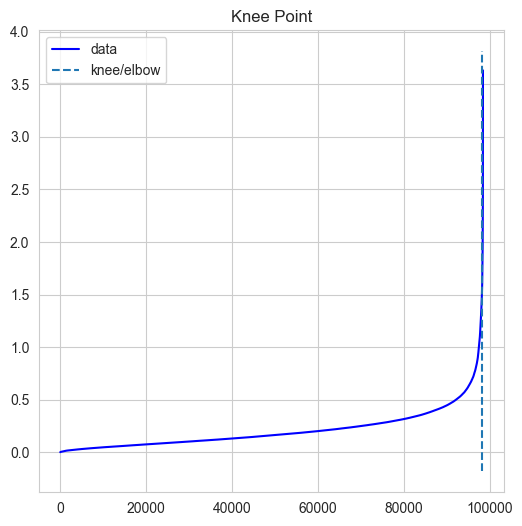

In [4]:
import matplotlib.pyplot as plt

kneedle.plot_knee()
plt.show()

In [5]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from collections import Counter

scaler = StandardScaler()
df = scaler.fit_transform(df)

clusters = DBSCAN(eps=kneedle.knee_y, min_samples=4).fit(df)
Counter(clusters.labels_)

Counter({-1: 90433,
         950: 49,
         165: 39,
         78: 38,
         172: 38,
         386: 34,
         215: 32,
         279: 31,
         388: 31,
         603: 31,
         1027: 30,
         697: 29,
         768: 29,
         1095: 29,
         41: 27,
         405: 27,
         593: 27,
         1100: 27,
         823: 26,
         123: 25,
         1012: 25,
         1016: 24,
         1131: 24,
         182: 23,
         790: 23,
         825: 23,
         1064: 23,
         50: 22,
         98: 22,
         573: 22,
         987: 22,
         1160: 22,
         524: 21,
         847: 21,
         986: 21,
         1126: 21,
         1198: 21,
         213: 20,
         276: 20,
         284: 20,
         460: 20,
         770: 20,
         927: 20,
         25: 19,
         432: 19,
         680: 19,
         990: 19,
         43: 18,
         88: 18,
         258: 18,
         262: 18,
         318: 18,
         352: 18,
         525: 18,
         589: 18,
     

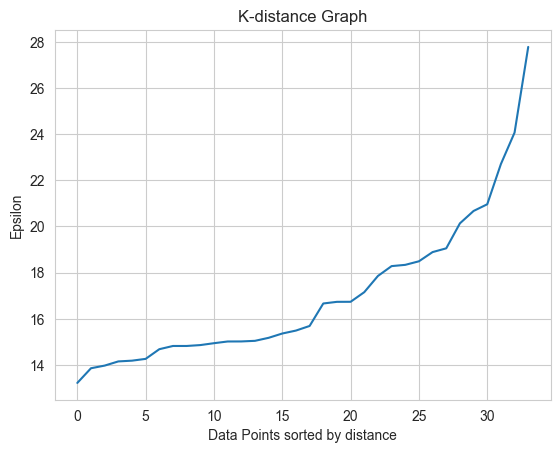

[ 0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0 -1  0 -1  0  0  0
  0  0  0 -1  0  0  0  0  0  0]


In [50]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

scaler = StandardScaler()
scaled_features = scaler.fit_transform(aggregated_df)

# Compute the k-nearest neighbors
k = 22 # You can adjust this value
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(scaled_features)
distances, indices = neighbors_fit.kneighbors(scaled_features)

# Sort the distances (4th column) and plot
distances = np.sort(distances[:, k-1], axis=0)
plt.plot(distances)
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon')
plt.title('K-distance Graph')
plt.show()

dbscan = DBSCAN(eps=11, min_samples=2)
clusters = dbscan.fit_predict(scaled_features)
print(clusters)

    Principal Component 1  Principal Component 2  Cluster
0                4.018628               0.059817        0
1               -3.689364              -0.038992        0
2               -3.765920               1.376447        0
3               -3.170914               5.861976        0
4              -17.091104              -4.926505        0
5               -8.147050               2.452318        0
6                3.850999              12.950008       -1
7                0.664597               4.848649        0
8                8.235571              -5.167645        0
9                3.309637               1.225280        0
10               3.072024               1.379708        0
11             -11.347773              -1.023158        0
12              -0.658020               1.063362        0
13               6.649855              -2.528021        0
14              12.636031              -7.248039        0
15               5.092781              -2.177808        0
16            

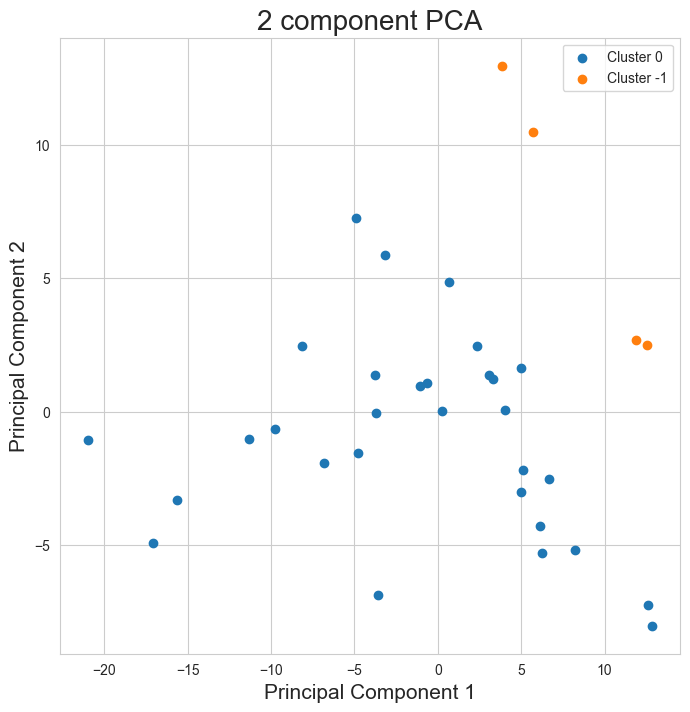

In [41]:
import pandas as pd
from sklearn.decomposition import PCA

# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(scaled_features)

# Create a DataFrame that will have the PCA1 and PCA2 values
principalDf = pd.DataFrame(data=principalComponents, columns=['Principal Component 1', 'Principal Component 2'])

# Concatenate the clusters labels to the DataFrame
finalDf = pd.concat([principalDf, pd.DataFrame({"Cluster": clusters})], axis=1)
print(finalDf)

# Plot the clusters
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel('Principal Component 1', fontsize=15)
ax.set_ylabel('Principal Component 2', fontsize=15)
ax.set_title('2 component PCA', fontsize=20)

# Plot each cluster with a different color
unique_clusters = finalDf['Cluster'].unique()
for cluster in unique_clusters:
    cluster_data = finalDf[finalDf['Cluster'] == cluster]
    ax.scatter(cluster_data['Principal Component 1'], cluster_data['Principal Component 2'], label=f'Cluster {cluster}')

ax.legend()
plt.show()